In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [2]:
df = pd.read_csv('train.csv')


In [ ]:
print("Jumlah data:", len(df))
print("Jumlah data null:\n", df.isnull().sum())

# Isi nilai kosong BMI dengan mean
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

# === 3. ENCODING KATEGORIK ===
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df[col] = le.fit_transform(df[col])

Jumlah data: 891
Jumlah data null:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
X = df.drop(columns=['id', 'stroke'])
y = df['stroke']

# === 5. NORMALISASI FITUR ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# === 6. TRAIN TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# === 7. TRAIN MODEL ===
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = model.predict(X_test)

# === 9. EVALUASI MODEL ===
print("\nAkurasi Model: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))




Akurasi Model: 81.01%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



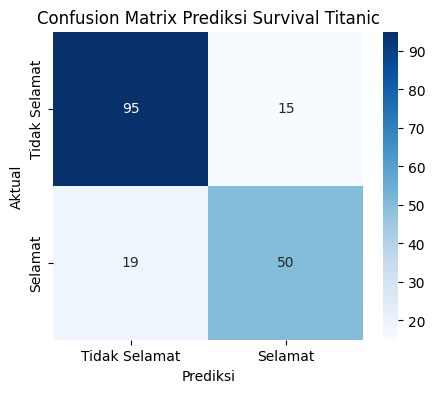

In [ ]:
# === 10. CONFUSION MATRIX ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Stroke', 'Stroke'], yticklabels=['Tidak Stroke', 'Stroke'])
plt.title("Confusion Matrix Prediksi Stroke")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

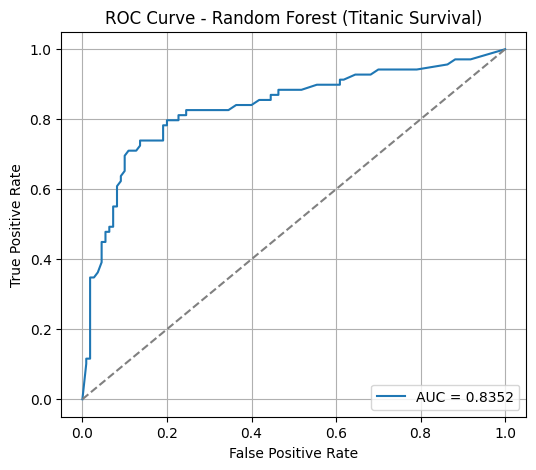


ROC AUC Score: 0.8352


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")


=== Feature Importances ===
Fare        0.311312
Age         0.286020
Sex         0.273722
Pclass      0.092538
Embarked    0.036408
dtype: float64


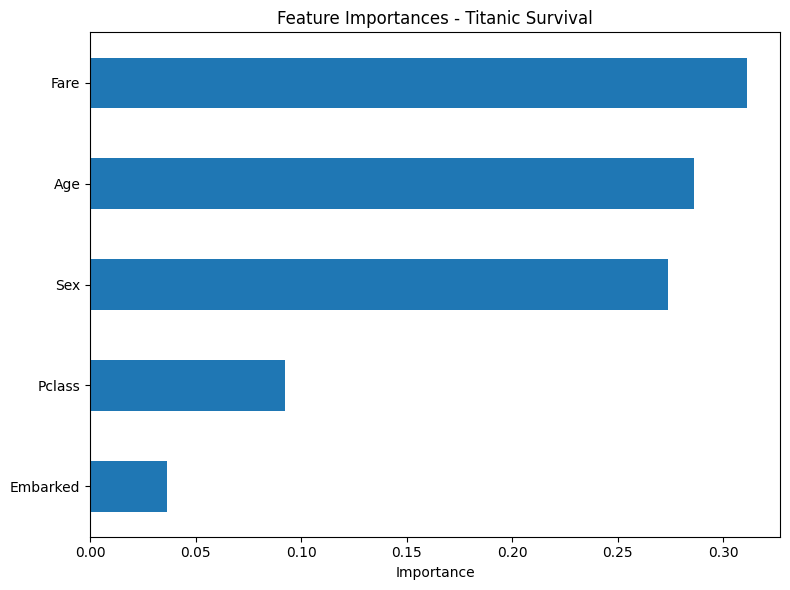

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n=== Top 10 Feature Importances ===")
print(importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

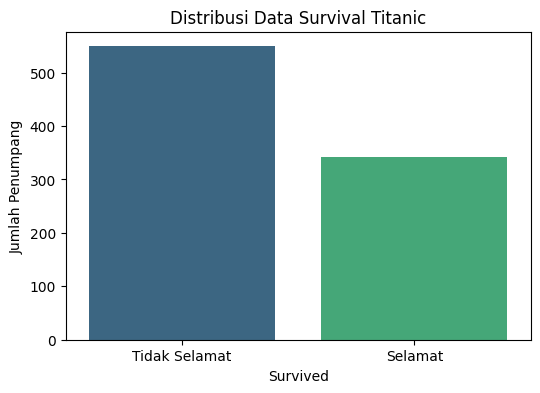

In [ ]:
# === 11. VISUALISASI DISTRIBUSI STROKE ===
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Distribusi Data Stroke vs Tidak Stroke')
plt.xticks([0,1], ['Tidak Stroke', 'Stroke'])
plt.ylabel('Jumlah Pasien')
plt.show()